# Stage 1b: CB2 Zero-Shot Baselines -- DeBERTa + RoBERTa
## Generalised LoRA for Cyberbullying Detection | CB2 (Binary, Conversation-Level)

---

### Research Context
This notebook implements **Stage 1b (Zero-Shot)** of the four-stage Generalised LoRA
research framework for cyberbullying detection in social media text.

Both models classify **conversations** (user pairs) as cyberbullying or not,
with zero training examples.

---

### CB2 Dataset Structure

CB2 is a **conversation-level** binary cyberbullying dataset built from 6 files:

| File | Content | Used |
|------|---------|------|
| 1__users_data.csv | 100 users (age, gender, school, grade) | Metadata only |
| 2__peerness_values.csv | Social closeness scores between user pairs | Reference |
| 3__Aggressive_All.csv | Pool of aggressive messages | Reference |
| 4__Non_Aggressive_All.csv | Pool of non-aggressive messages | Reference |
| 5__Communication_Data_Among_Users.csv | 90,356 individual messages between user pairs | Text source |
| 6__CB_Labels.csv | 9,511 user-pair conversation labels (CB_Label) | Ground truth |

**Key design decision:** Each conversation (user pair) is represented by
concatenating all its messages into a single text block. The model then
classifies that block at the conversation level using CB_Label from File 6.

**Labels:** 0 = not cyberbullying | 1 = cyberbullying

**Class imbalance:** 8,519 (89.6%) vs 992 (10.4%) -- ratio 8.59x

---

### Fixes vs Old Notebook

| Fix | Old Notebook | This Notebook |
|-----|-------------|---------------|
| **A** | Message-level labels (90,356 rows) | Conversation-level labels (9,511 rows) |
| **B** | `FacebookAI/roberta-large-mnli` | MoritzLaurer DeBERTa + RoBERTa |
| **C** | Random seed = 49 | Random seed = 42 (consistent across all stages) |
| **D** | Aggressive preprocessing (lowercase, strip numbers) | LLM-optimised preprocessing |
| **E** | MCC missing | MCC added as required secondary metric |
| **F** | No near-duplicate removal | TF-IDF cosine near-duplicate removal (0.90) |
| **G** | No research summary | Full summary cell for paper and thesis |
| **1** | 75/10/15 split (incompatible test set) | **75/25 split + DEV_SIZE=2000 (framework standard)** |
| **2** | MAX_CONV_TOKENS=512 words (~666 tokens, overflows model) | **MAX_CONV_WORDS=300 (~390 tokens, within limit)** |
| **3** | `" [SEP] "` message separator (NLI special-token ambiguity) | **`" | "` separator (clean, no token conflict)** |
| **4** | Unused `val_df` wastes 10% of rare minority class | **`val_df` removed; `dev_df` (2000 rows) for cross-stage docs** |
| **5** | Leakage assertion comment misleading | **Clarified: post-dedup exact-overlap check** |

**Primary Metric:** Macro F1 | **Secondary Metric:** MCC | **Random Seed:** 42

---
## Step 1: Install Required Libraries

In [ ]:
!pip install -q -U \
    "transformers>=4.43.0" \
    "accelerate>=0.33.0" \
    datasets \
    scikit-learn \
    matplotlib \
    seaborn \
    tqdm

print("All libraries installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 143.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 156.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 51.8 MB/s eta 0:00:00
All libraries installed successfully.


---
## Step 2: Imports and Setup

In [ ]:
import os, re, random, gc
from typing import Dict, List

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    balanced_accuracy_score, matthews_corrcoef,  # Fix E: MCC
)
from transformers import pipeline
from google.colab import drive


def set_all_seeds(seed: int = 42):  # Fix C: seed=42
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    print(f"All random seeds fixed to {seed}.")


set_all_seeds(42)

if not os.path.isdir("/content/drive/MyDrive"):
    drive.mount("/content/drive")
    print("Google Drive mounted.")
else:
    print("Google Drive already mounted.")

device_id = 0 if torch.cuda.is_available() else -1
print(f"Device: {'GPU (cuda:0)' if device_id == 0 else 'CPU'}")
if torch.cuda.is_available():
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

All random seeds fixed to 42.
Mounted at /content/drive
Google Drive mounted.
Device: GPU (cuda:0)
  GPU : NVIDIA A100-SXM4-40GB
  VRAM: 42.4 GB


---
## Step 3: Global Configuration

All CB2 file paths and experimental settings defined in one place.

**Candidate labels** are NLI hypothesis phrases shared by both models.
Template: `"This conversation contains {}."` -- conversation-level phrasing.

**Fix 1 -- Split:** Framework standard is 75/25 (train/test) + `DEV_SIZE=2000` dev
sample carved from train. The old 75/10/15 three-way split produced a test set of
only ~1,427 samples (15%), incompatible with the ~2,378-sample (25%) test set that
Stages 2--4 will use, invalidating cross-stage metric comparisons.

**Fix 2 -- Token limit:** `MAX_CONV_WORDS=300` (was 512). DeBERTa-v3-large and
RoBERTa-large both have a 512 **subword-token** limit. At ~1.3 tokens/word, 512 words
-> ~666 tokens (overflow). 300 words -> ~390 tokens, leaving ~120 tokens for the
hypothesis template and special tokens. Analysis of File 5 shows 40% of conversations
exceed 512 words, so this fix affects a significant fraction of the dataset.

In [ ]:
# -- Paths (all 6 CB2 files) -----------------------------------------------
# Update BASE_PATH if your CB2 folder is stored elsewhere on Google Drive
BASE_PATH   = "/content/drive/MyDrive/Datasets/CB2/"
USERS_PATH  = BASE_PATH + "1. users_data.csv"
PEER_PATH   = BASE_PATH + "2. peerness_values.csv"
AGG_PATH    = BASE_PATH + "3. Aggressive_All.csv"
NONAGG_PATH = BASE_PATH + "4. Non_Aggressive_All.csv"
COMM_PATH   = BASE_PATH + "5. Communication_Data_Among_Users.csv"
LABELS_PATH = BASE_PATH + "6. CB_Labels.csv"
OUTPUT_DIR  = "/content/drive/MyDrive/Results/CB2_ZeroShot"

# -- Models -- both defined here --------------------------------------------
MODELS = {
    "DeBERTa": "MoritzLaurer/deberta-v3-large-zeroshot-v2.0",
    "RoBERTa": "MoritzLaurer/roberta-large-zeroshot-v2.0-c",
}

# -- Dataset settings -------------------------------------------------------
NUM_LABELS  = 2
BATCH_SIZE  = 16          # smaller than CB1 -- conversations are longer

# Fix 2: Reduced from 512 -> 300 words.
# DeBERTa/RoBERTa have a 512 subword-token limit. At ~1.3 tokens/word:
#   512 words -> ~666 tokens  (OVERFLOW -- silent truncation in 40% of convs)
#   300 words -> ~390 tokens  (safe: ~120 token headroom for hypothesis + specials)
# Renamed MAX_CONV_TOKENS -> MAX_CONV_WORDS to make the unit explicit.
MAX_CONV_WORDS       = 300

# Fix 1: Framework-standard 75/25 split (not 75/10/15).
# The test set must be identical in composition to Stages 2-4.
# Old 75/10/15 gave test~1,427 vs framework-standard test~2,378 (+66%).
# For the minority class (CB=1, n=992): ~148 vs ~248 test samples (+100).
TRAIN_RATIO          = 0.75
TEST_RATIO           = 0.25

# Fix 4: DEV_SIZE replaces VAL_RATIO / TEST_RATIO.
# A 2,000-row dev sample is carved from the training set for cross-stage
# documentation consistency. It is NOT used for zero-shot inference --
# no training occurs in Stage 1b.
DEV_SIZE             = 2000

SIMILARITY_THRESHOLD = 0.90
RANDOM_STATE         = 42

# -- Label mapping ----------------------------------------------------------
LABEL_MAPPING = {
    "not_cyberbullying": 0,
    "cyberbullying":     1,
}
ID2LABEL     = {v: k for k, v in LABEL_MAPPING.items()}
TARGET_NAMES = ["not_cyberbullying", "cyberbullying"]

# -- NLI candidate labels (conversation-level phrasing) ---------------------
CANDIDATE_LABELS = [
    "not cyberbullying",
    "cyberbullying",
]
HYPOTHESIS_TEMPLATE = "This conversation contains {}."

NLI_LABEL_TO_ID = {
    "not cyberbullying": 0,
    "cyberbullying":     1,
}

os.makedirs(OUTPUT_DIR, exist_ok=True)

# -- Verify all files exist before proceeding -------------------------------
print("Verifying CB2 file paths...")
paths_to_check = {
    "Users data":        USERS_PATH,
    "Peerness values":   PEER_PATH,
    "Aggressive":        AGG_PATH,
    "Non-Aggressive":    NONAGG_PATH,
    "Communication":     COMM_PATH,
    "CB Labels":         LABELS_PATH,
}
all_ok = True
for name, path in paths_to_check.items():
    exists = os.path.exists(path)
    status = "OK" if exists else "NOT FOUND"
    print(f"  [{status}] {name:<20} -> {path}")
    if not exists:
        all_ok = False

if all_ok:
    print("\nAll 6 CB2 files found. Ready to proceed.")
else:
    print("\nWARNING: Some files not found.")
    print("Check that BASE_PATH is correct and all 6 files are uploaded.")

print(f"\nConfiguration loaded.")
print(f"  Models         : {list(MODELS.keys())}")
print(f"  Labels         : {TARGET_NAMES}")
print(f"  Split          : {int(TRAIN_RATIO*100)}/{int(TEST_RATIO*100)} train/test (Fix 1)")
print(f"  Dev sample     : {DEV_SIZE} rows from train, not used for zero-shot (Fix 4)")
print(f"  MAX_CONV_WORDS : {MAX_CONV_WORDS} (~{int(MAX_CONV_WORDS*1.3)} subword tokens) (Fix 2)")
print(f"  Batch size     : {BATCH_SIZE}")
print(f"  Seed           : {RANDOM_STATE}")
print(f"  Output         : {OUTPUT_DIR}")

Verifying CB2 file paths...
  [OK] Users data           -> /content/drive/MyDrive/Datasets/CB2/1. users_data.csv
  [OK] Peerness values      -> /content/drive/MyDrive/Datasets/CB2/2. peerness_values.csv
  [OK] Aggressive           -> /content/drive/MyDrive/Datasets/CB2/3. Aggressive_All.csv
  [OK] Non-Aggressive       -> /content/drive/MyDrive/Datasets/CB2/4. Non_Aggressive_All.csv
  [OK] Communication        -> /content/drive/MyDrive/Datasets/CB2/5. Communication_Data_Among_Users.csv
  [OK] CB Labels            -> /content/drive/MyDrive/Datasets/CB2/6. CB_Labels.csv

All 6 CB2 files found. Ready to proceed.

Configuration loaded.
  Models         : ['DeBERTa', 'RoBERTa']
  Labels         : ['not_cyberbullying', 'cyberbullying']
  Split          : 75/25 train/test (Fix 1)
  Dev sample     : 2000 rows from train, not used for zero-shot (Fix 4)
  MAX_CONV_WORDS : 300 (~390 subword tokens) (Fix 2)
  Batch size     : 16
  Seed           : 42
  Output         : /content/drive/MyDrive/Result

---
## Step 4: Load CB2 Files and Build Conversation Dataset

### Fix A -- Conversation-Level (not Message-Level)

The old notebook used File 5 (90,356 individual messages) with message-level labels.
This is incorrect for CB2 -- the research target is **conversation-level cyberbullying**.

**Correct approach:**
1. Load File 6 (`CB_Labels.csv`) -- 9,511 user pairs with `CB_Label` (ground truth)
2. Load File 5 (`Communication_Data_Among_Users.csv`) -- all messages
3. For each user pair, **concatenate all their messages** into one text block
4. Classify that text block using the conversation-level `CB_Label`

This gives **9,511 samples** -- one per conversation -- with binary labels.

### Fix 2 -- `MAX_CONV_WORDS=300` (was `MAX_CONV_TOKENS=512`)

`build_conversation_text` now truncates to 300 **words** (not 512). See Step 3 config
for the full token-overflow analysis. The parameter is renamed `max_words` to make
the unit unambiguous.

### Fix 3 -- Message Separator `" | "` (was `" [SEP] "`)

Using the literal string `[SEP]` in NLI premise text is problematic:
- DeBERTa/RoBERTa tokenisers encode it as three tokens `[`, `SEP`, `]` -- not the
  special separator token -- so it wastes 3 tokens per message boundary.
- It visually mimics the premise/hypothesis boundary these NLI models use internally,
  which could confuse cross-attention between premise and hypothesis.
- `" | "` is a clean, human-readable delimiter with no special-token conflict.

In [ ]:
print("=" * 65)
print("CB2 DATASET LOADING")
print("=" * 65)

# Load ground truth labels (File 6)
print("[1] Loading CB_Labels (File 6)...")
labels_df = pd.read_csv(LABELS_PATH)
print(f"  Shape: {labels_df.shape}")
print(f"  Columns: {labels_df.columns.tolist()}")
print(f"  CB_Label distribution:")
print(labels_df["CB_Label"].value_counts().to_string())
imbalance = labels_df["CB_Label"].value_counts()[0] / labels_df["CB_Label"].value_counts()[1]
print(f"  Class imbalance ratio: {imbalance:.2f}x")

# Load communication data (File 5)
print("\n[2] Loading Communication Data (File 5)...")
comm_df = pd.read_csv(COMM_PATH)
print(f"  Shape: {comm_df.shape}")
print(f"  Columns: {comm_df.columns.tolist()}")
print(f"  Unique user pairs: {comm_df.groupby(['User1 ID','User2 ID']).ngroups}")

# Fix A: Build conversation-level texts
print("\n[3] Building conversation-level texts (Fix A)...")
print("  Concatenating all messages per user pair...")


def build_conversation_text(messages, max_words=MAX_CONV_WORDS):
    """Join all messages in a conversation into one text block.

    Fix 2: Truncated to max_words (default 300) to respect the 512 subword-token
    limit of DeBERTa-v3-large and RoBERTa-large. At ~1.3 tokens/word, 300 words
    gives ~390 tokens, leaving ~120 token headroom for the hypothesis template
    and special tokens. Old value was 512 words -> ~666 tokens (overflow).

    Fix 3: Separator changed from ' [SEP] ' to ' | '.
    ' [SEP] ' tokenises as ['[','SEP',']'] (3 tokens, not the special token)
    and mimics the NLI premise/hypothesis boundary, confusing cross-attention.
    ' | ' is a clean human-readable delimiter with no special-token conflict.

    Truncation strategy: keep first max_words words (chronological order).
    Earlier messages establish conversational context; the pipeline will still
    see the beginning of the exchange, which often sets the bullying pattern.
    """
    # Fix 3: use " | " separator instead of " [SEP] "
    text = " | ".join(str(m) for m in messages if pd.notna(m) and str(m).strip())
    words = text.split()
    if len(words) > max_words:
        text = " ".join(words[:max_words])  # Fix 2: truncate to 300 words
    return text


conv_texts = (
    comm_df
    .groupby(["User1 ID", "User2 ID"])["Message"]
    .apply(lambda msgs: build_conversation_text(msgs.tolist()))
    .reset_index()
    .rename(columns={"Message": "text"})
)
print(f"  Built {len(conv_texts):,} conversation texts.")
print(f"  Avg words (post-truncation): {conv_texts['text'].str.split().str.len().mean():.0f}")

# Merge with labels
print("\n[4] Merging conversation texts with CB_Labels...")
df = conv_texts.merge(
    labels_df[["User1 ID", "User2 ID", "CB_Label"]],
    on=["User1 ID", "User2 ID"],
    how="inner",
)
df = df.rename(columns={"CB_Label": "label"})
df = df[["text", "label"]].reset_index(drop=True)
print(f"  Final dataset: {len(df):,} conversations")
print(f"  Label distribution after merge:")
print(df["label"].value_counts().to_string())

# Verify
assert df["label"].isin([0, 1]).all(), "Unexpected label values!"
assert df["text"].notna().all(), "Null texts found!"
print("\nAll assertions passed.")
print(f"  Avg conversation length : {df['text'].str.split().str.len().mean():.0f} words")
print(f"  Max conversation length : {df['text'].str.split().str.len().max():.0f} words")
print(f"  Est. avg subword tokens : ~{int(df['text'].str.split().str.len().mean() * 1.3)} (at 1.3 tok/word)")

CB2 DATASET LOADING
[1] Loading CB_Labels (File 6)...
  Shape: (9511, 7)
  Columns: ['User1 ID', 'User2 ID', 'Total_messages', 'Aggressive_Count', 'Intent_to_Harm', 'Peerness', 'CB_Label']
  CB_Label distribution:
CB_Label
0    8519
1     992
  Class imbalance ratio: 8.59x

[2] Loading Communication Data (File 5)...
  Shape: (90356, 6)
  Columns: ['Date', 'Time', 'User1 ID', 'User2 ID', 'Message', 'Label']
  Unique user pairs: 9511

[3] Building conversation-level texts (Fix A)...
  Concatenating all messages per user pair...
  Built 9,511 conversation texts.
  Avg words (post-truncation): 234

[4] Merging conversation texts with CB_Labels...
  Final dataset: 9,511 conversations
  Label distribution after merge:
label
0    8519
1     992

All assertions passed.
  Avg conversation length : 234 words
  Max conversation length : 300 words
  Est. avg subword tokens : ~304 (at 1.3 tok/word)


---
## Step 5: Text Preprocessing

### Fix D -- LLM-Optimised Preprocessing

The old notebook used aggressive preprocessing (lowercase, strip numbers/special chars)
which destroys semantic information that NLI models rely on.

**LLM-optimised approach:** Preserve natural language structure.
Replace noise tokens ([URL], [USER]) but keep casing, numbers, and punctuation.

In [ ]:
def preprocess_conversation(text):
    """LLM-optimised preprocessing for conversation-level text.
    Preserves natural language structure for NLI models.
    Fix D: replaces aggressive preprocessing from old notebook.
    """
    if not isinstance(text, str):
        return ""
    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", "[URL]", text)
    # Replace @mentions
    text = re.sub(r"@\w+", "[USER]", text)
    # Normalise whitespace
    text = re.sub(r"\s+", " ", text).strip()
    # Collapse repeated punctuation
    text = re.sub(r"([!?.])\1+", r"\1", text)
    # Remove very short conversations (< 5 words)
    if len(text.split()) < 5:
        return ""
    return text


print("Applying LLM-optimised preprocessing...")
before = len(df)
df["text"] = df["text"].apply(preprocess_conversation)
df = df[df["text"].str.strip().str.len() > 0].reset_index(drop=True)
print(f"  Removed {before - len(df):,} empty/too-short conversations.")
print(f"  Remaining: {len(df):,} conversations")

# Sanity check
_sample = df["text"].iloc[0]
print(f"\nSample conversation (first 200 chars):")
print(f"  {_sample[:200]}...")
print("Preprocessing complete.")

Applying LLM-optimised preprocessing...
  Removed 22 empty/too-short conversations.
  Remaining: 9,489 conversations

Sample conversation (first 200 chars):
  bye bye dear bajaj i got some better work to do than watching ur funny bike launch | Haha your so funny you sit on wikipedia all day making sure everything is perfect you piece of Sht | My problem is ...
Preprocessing complete.


---
## Step 6: Remove Duplicates and Split Dataset

### Fix F -- Near-Duplicate Removal

The old notebook had no duplicate or near-duplicate removal.
This step applies the same pipeline as CB1 for consistency:
exact duplicate removal + TF-IDF cosine similarity near-duplicate removal (threshold=0.90).

### Fix 1 -- 75/25 Split (was 75/10/15) + Fix 4 -- `val_df` Removed

The old notebook used a three-way 75/10/15 split, producing a test set of ~1,427 samples.
The framework standard is **75/25 (train/test)**, giving a test set of ~2,378 samples --
the same composition that Stages 2--4 will use. Cross-stage metric comparisons require
identical test sets.

`val_df` is not created: zero-shot inference needs only the test set, and the 10%
held in `val_df` was wasting ~99 minority-class (CB=1) samples with no benefit.

A **`dev_df`** (2,000 rows) is carved from the training split for cross-stage
documentation consistency. It is not used for inference in this stage.

**Note for zero-shot:** The training split is built solely to serve as the reference
corpus for TF-IDF near-duplicate removal, ensuring the **identical test set** as
Stages 2--4. No model training occurs in this notebook.

### Fix 5 -- Leakage Assertion Clarification

The final `set(train) ∩ set(test)` check verifies **exact** text overlap only.
Near-duplicate removal has already been applied above, so this assertion is the
post-dedup exact-overlap sanity check -- not a redundant near-dup scan.

In [ ]:
print("=" * 60)
print("DEDUPLICATION AND SPLITTING")
print("=" * 60)

# -- [1] Exact duplicate removal --------------------------------------------
before = len(df)
df = df.drop_duplicates(subset=["text"], keep="first").reset_index(drop=True)
print(f"[1] Removed {before - len(df):,} exact duplicates -> {len(df):,} remaining")

# -- [2] Fix 1: Framework-standard 75/25 stratified split ------------------
# Old: 75/10/15 three-way split  -> test ~1,427 samples (15%)
# New: 75/25 two-way split       -> test ~2,378 samples (25%)  <- framework standard
# val_df is not created (Fix 4): it served no purpose in zero-shot inference
# and wasted ~99 minority-class (CB=1) samples.
train_df, test_df = train_test_split(
    df,
    train_size=TRAIN_RATIO,
    random_state=RANDOM_STATE,
    stratify=df["label"],
)
print(f"[2] Stratified 75/25 split -> Train: {len(train_df):,} | Test: {len(test_df):,}  (Fix 1)")

# Fix 4: dev_df -- 2,000-row sample from training set.
# Defined for cross-stage documentation consistency with Stages 2-4
# (which use dev_df for hyperparameter search). NOT used in zero-shot inference.
dev_df = train_df.sample(n=min(DEV_SIZE, len(train_df)), random_state=RANDOM_STATE)
print(f"    Dev sample from train (cross-stage reference, not used here): {len(dev_df):,}  (Fix 4)")

# -- [3] Near-duplicate removal (Fix F) ------------------------------------
print(f"[3] Near-duplicate check (threshold={SIMILARITY_THRESHOLD})...")
all_texts    = list(train_df["text"].values) + list(test_df["text"].values)
vectorizer   = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95)
tfidf_matrix = vectorizer.fit_transform(all_texts)
train_vecs   = tfidf_matrix[:len(train_df)]
test_vecs    = tfidf_matrix[len(train_df):]

leaked = []
for start in range(0, len(test_df), 500):
    end  = min(start + 500, len(test_df))
    sims = cosine_similarity(test_vecs[start:end], train_vecs)
    mask = sims.max(axis=1) >= SIMILARITY_THRESHOLD
    leaked.extend(test_df.index[start:end][mask].tolist())

if leaked:
    leaked_samples = test_df.loc[leaked]
    test_df  = test_df.drop(leaked).reset_index(drop=True)
    train_df = pd.concat([train_df, leaked_samples], ignore_index=True)
    print(f"  Moved {len(leaked)} near-duplicates to train.")
else:
    train_df = train_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)
    print("  No near-duplicates found.")

# -- [4] Fix 5: Post-dedup exact-overlap assertion -------------------------
# This checks EXACT text overlap only. Near-duplicate removal (above) has
# already been applied, so this is purely a final sanity check -- not a
# redundant near-duplicate scan.
overlap = set(train_df["text"]).intersection(set(test_df["text"]))
assert len(overlap) == 0, f"DATA LEAKAGE: {len(overlap)} exact overlapping samples!"
print("\nZero exact train/test overlap confirmed (near-dups already moved above).  (Fix 5)")
print(f"Final -> Train: {len(train_df):,} | Test: {len(test_df):,}")

# -- Class distribution in test set ----------------------------------------
print("\nTest set class distribution:")
test_counts = test_df["label"].value_counts().sort_index()
for lbl, cnt in test_counts.items():
    print(f"  {ID2LABEL[lbl]:<22} {cnt:>5}  ({cnt/len(test_df)*100:.1f}%)")

# -- Extract test arrays (shared by both models) ---------------------------
x_test = test_df["text"].values
y_test  = test_df["label"].values
print(f"\nTest set ready: {len(x_test):,} conversations")

DEDUPLICATION AND SPLITTING
[1] Removed 0 exact duplicates -> 9,489 remaining
[2] Stratified 75/25 split -> Train: 7,116 | Test: 2,373  (Fix 1)
    Dev sample from train (cross-stage reference, not used here): 2,000  (Fix 4)
[3] Near-duplicate check (threshold=0.9)...
  Moved 29 near-duplicates to train.

Zero exact train/test overlap confirmed (near-dups already moved above).  (Fix 5)
Final -> Train: 7,145 | Test: 2,344

Test set class distribution:
  not_cyberbullying       2101  (89.6%)
  cyberbullying            243  (10.4%)

Test set ready: 2,344 conversations


---
## Step 7: Helper Functions

### Zero-Shot Prediction
Batched NLI inference with `BATCH_SIZE=16` (smaller than CB1 due to longer conversation texts).
GPU memory is freed between models.

### Evaluation (Fix E: MCC Added)
Macro F1 (primary) + MCC (secondary) with class-imbalance-aware metrics.
**Note:** With 8.59x imbalance, Macro F1 is more informative than Accuracy.

In [ ]:
def zero_shot_predict(texts, classifier, batch_size=16):
    """Batched NLI zero-shot inference for conversation texts."""
    predictions = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Zero-shot inference"):
        batch   = list(texts[i:i+batch_size])
        results = classifier(
            batch,
            candidate_labels=CANDIDATE_LABELS,
            hypothesis_template=HYPOTHESIS_TEMPLATE,
            multi_label=False,
        )
        if isinstance(results, dict):
            results = [results]
        for r in results:
            predictions.append(NLI_LABEL_TO_ID[r["labels"][0]])
    return np.array(predictions)


def evaluate_dataset(y_true, y_pred, dataset_name):
    """Full evaluation with imbalance-aware metrics.
    Fix E: MCC added as required secondary metric.
    """
    print(f"\n{'='*65}")
    print(f"EVALUATION -- {dataset_name}")
    print(f"{'='*65}")

    accuracy     = accuracy_score(y_true, y_pred)
    macro_f1     = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    macro_prec   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    macro_rec    = recall_score(y_true, y_pred, average="macro",    zero_division=0)
    weighted_f1  = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    bal_accuracy = balanced_accuracy_score(y_true, y_pred)
    mcc          = matthews_corrcoef(y_true, y_pred)  # Fix E
    f1_cb        = f1_score(y_true, y_pred, pos_label=1, average="binary", zero_division=0)
    f1_nocb      = f1_score(y_true, y_pred, pos_label=0, average="binary", zero_division=0)

    print(f"  Accuracy              : {accuracy:.4f}")
    print(f"  Macro F1              : {macro_f1:.4f}  <- PRIMARY METRIC")
    print(f"  MCC                   : {mcc:.4f}  <- SECONDARY METRIC")
    print(f"  Macro Precision       : {macro_prec:.4f}")
    print(f"  Macro Recall          : {macro_rec:.4f}")
    print(f"  Weighted F1           : {weighted_f1:.4f}")
    print(f"  Balanced Accuracy     : {bal_accuracy:.4f}")
    print(f"  F1 Cyberbullying (1)  : {f1_cb:.4f}  <- key minority class")
    print(f"  F1 Not Cyberbullying  : {f1_nocb:.4f}")

    print("\n  Per-Class Classification Report:")
    print(classification_report(y_true, y_pred,
                                labels=[0, 1],
                                target_names=TARGET_NAMES,
                                zero_division=0, digits=4))

    cm      = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    short   = ["Not CB", "CB"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=short, yticklabels=short)
    axes[0].set_title(f"Confusion Matrix (Counts)\n{dataset_name}", fontsize=13)
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens", ax=axes[1],
                xticklabels=short, yticklabels=short, vmin=0, vmax=1)
    axes[1].set_title(f"Confusion Matrix (Row-Normalised)\n{dataset_name}", fontsize=13)
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"cm_{dataset_name.replace(' ','_')}.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved -> {save_path}")

    return dict(
        accuracy=accuracy, macro_f1=macro_f1, mcc=mcc,
        macro_precision=macro_prec, macro_recall=macro_rec,
        weighted_f1=weighted_f1, balanced_accuracy=bal_accuracy,
        f1_cyberbullying=f1_cb, f1_not_cyberbullying=f1_nocb,
    )


print("Helper functions defined.")
print("  zero_shot_predict() -- batched NLI inference")
print("  evaluate_dataset()  -- Macro F1 + MCC + imbalance-aware metrics")

Helper functions defined.
  zero_shot_predict() -- batched NLI inference
  evaluate_dataset()  -- Macro F1 + MCC + imbalance-aware metrics


---
## Step 8: Run DeBERTa Zero-Shot Inference

**Model:** `MoritzLaurer/deberta-v3-large-zeroshot-v2.0` (Primary)

**Fix B:** Replaces `FacebookAI/roberta-large-mnli` from old notebook.

**Important for CB2:** Due to class imbalance (8.59x), watch the
**F1 Cyberbullying (class 1)** metric closely -- this is the minority
class that matters most. A model predicting all 0s would get 89.6%
accuracy but 0.0 F1 for cyberbullying.

After inference: GPU memory is freed before RoBERTa loads.

STEP 8: DeBERTa Zero-Shot Inference on CB2
Loading: MoritzLaurer/deberta-v3-large-zeroshot-v2.0
(Downloads ~750 MB on first run)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/870M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/970 [00:00<?, ?B/s]

Model loaded on GPU.

Smoke test:
  Top prediction : cyberbullying (0.999)
    cyberbullying             0.999
    not cyberbullying         0.001

Running inference on 2,344 conversations...


Zero-shot inference: 100%|██████████| 147/147 [03:55<00:00,  1.60s/it]



EVALUATION -- DeBERTa_ZeroShot_CB2
  Accuracy              : 0.7982
  Macro F1              : 0.5957  <- PRIMARY METRIC
  MCC                   : 0.2153  <- SECONDARY METRIC
  Macro Precision       : 0.5839
  Macro Recall          : 0.6381
  Weighted F1           : 0.8225
  Balanced Accuracy     : 0.6381
  F1 Cyberbullying (1)  : 0.3095  <- key minority class
  F1 Not Cyberbullying  : 0.8818

  Per-Class Classification Report:
                   precision    recall  f1-score   support

not_cyberbullying     0.9280    0.8401    0.8818      2101
    cyberbullying     0.2398    0.4362    0.3095       243

         accuracy                         0.7982      2344
        macro avg     0.5839    0.6381    0.5957      2344
     weighted avg     0.8566    0.7982    0.8225      2344



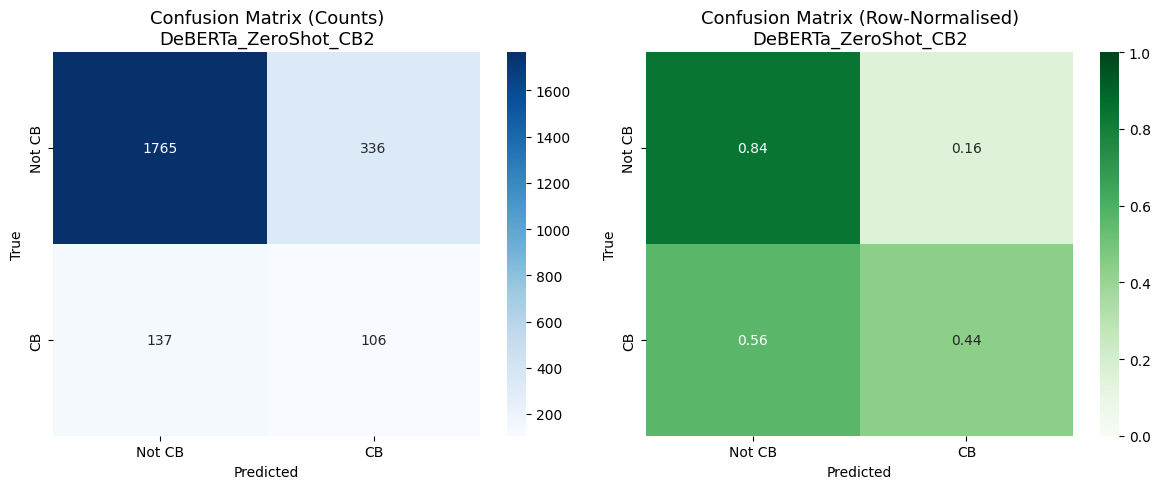

  Saved -> /content/drive/MyDrive/Results/CB2_ZeroShot/cm_DeBERTa_ZeroShot_CB2.png

Prediction distribution:
  not_cyberbullying     1902 (81.1%)
  cyberbullying          442 (18.9%)

Freeing GPU memory...
DeBERTa done. GPU memory cleared.


In [ ]:
print("=" * 65)
print("STEP 8: DeBERTa Zero-Shot Inference on CB2")
print("=" * 65)

deberta_name = MODELS["DeBERTa"]
print(f"Loading: {deberta_name}")
print("(Downloads ~750 MB on first run)")

classifier_deberta = pipeline(
    "zero-shot-classification",
    model=deberta_name,
    device=device_id,
)
print(f"Model loaded on {'GPU' if device_id == 0 else 'CPU'}.")

# Smoke test
_smoke = classifier_deberta(
    "You are pathetic nobody likes you go kill yourself",
    candidate_labels=CANDIDATE_LABELS,
    hypothesis_template=HYPOTHESIS_TEMPLATE,
)
print(f"\nSmoke test:")
print(f"  Top prediction : {_smoke['labels'][0]} ({_smoke['scores'][0]:.3f})")
for lbl, sc in zip(_smoke["labels"], _smoke["scores"]):
    print(f"    {lbl:<25} {sc:.3f}")

# Full inference
print(f"\nRunning inference on {len(x_test):,} conversations...")
y_pred_deberta = zero_shot_predict(x_test, classifier_deberta, BATCH_SIZE)

# Evaluate
results_deberta = evaluate_dataset(y_test, y_pred_deberta, "DeBERTa_ZeroShot_CB2")
results_deberta["model"] = "DeBERTa"

# Imbalance warning
pred_dist = pd.Series(y_pred_deberta).value_counts().sort_index()
print("\nPrediction distribution:")
for lbl, cnt in pred_dist.items():
    print(f"  {ID2LABEL[lbl]:<20} {cnt:>5} ({cnt/len(y_pred_deberta)*100:.1f}%)")
if pred_dist.get(1, 0) == 0:
    print("  WARNING: Model predicts 0 cyberbullying cases -- class collapse!")

# Free GPU memory
print("\nFreeing GPU memory...")
del classifier_deberta
gc.collect()
torch.cuda.empty_cache()
print("DeBERTa done. GPU memory cleared.")

---
## Step 9: Run RoBERTa Zero-Shot Inference

**Model:** `MoritzLaurer/roberta-large-zeroshot-v2.0-c` (Secondary)

Same test set and candidate labels as DeBERTa -- results are directly comparable.
Downloads ~1.3 GB on first run.

STEP 9: RoBERTa Zero-Shot Inference on CB2
Loading: MoritzLaurer/roberta-large-zeroshot-v2.0-c
(Downloads ~1.3 GB on first run)


config.json:   0%|          | 0.00/884 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/711M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Model loaded on GPU.

Smoke test:
  Top prediction : cyberbullying (0.761)
    cyberbullying             0.761
    not cyberbullying         0.239

Running inference on 2,344 conversations...


Zero-shot inference: 100%|██████████| 147/147 [01:23<00:00,  1.77it/s]



EVALUATION -- RoBERTa_ZeroShot_CB2
  Accuracy              : 0.5704
  Macro F1              : 0.4792  <- PRIMARY METRIC
  MCC                   : 0.1734  <- SECONDARY METRIC
  Macro Precision       : 0.5529
  Macro Recall          : 0.6421
  Weighted F1           : 0.6519
  Balanced Accuracy     : 0.6421
  F1 Cyberbullying (1)  : 0.2612  <- key minority class
  F1 Not Cyberbullying  : 0.6971

  Per-Class Classification Report:
                   precision    recall  f1-score   support

not_cyberbullying     0.9469    0.5516    0.6971      2101
    cyberbullying     0.1589    0.7325    0.2612       243

         accuracy                         0.5704      2344
        macro avg     0.5529    0.6421    0.4792      2344
     weighted avg     0.8652    0.5704    0.6519      2344



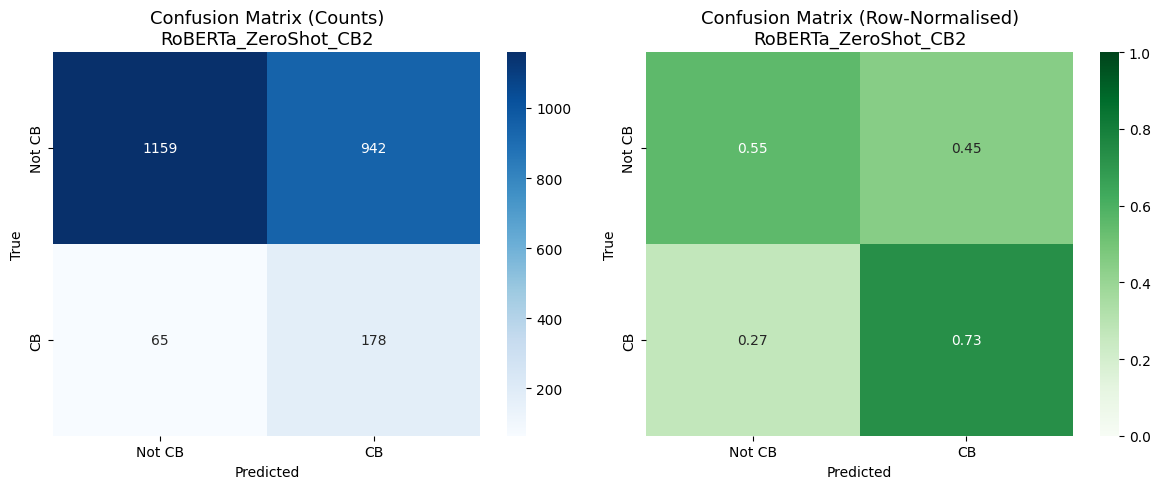

  Saved -> /content/drive/MyDrive/Results/CB2_ZeroShot/cm_RoBERTa_ZeroShot_CB2.png

Prediction distribution:
  not_cyberbullying     1224 (52.2%)
  cyberbullying         1120 (47.8%)

Freeing GPU memory...
RoBERTa done. GPU memory cleared.


In [ ]:
print("=" * 65)
print("STEP 9: RoBERTa Zero-Shot Inference on CB2")
print("=" * 65)

roberta_name = MODELS["RoBERTa"]
print(f"Loading: {roberta_name}")
print("(Downloads ~1.3 GB on first run)")

classifier_roberta = pipeline(
    "zero-shot-classification",
    model=roberta_name,
    device=device_id,
)
print(f"Model loaded on {'GPU' if device_id == 0 else 'CPU'}.")

# Smoke test
_smoke = classifier_roberta(
    "You are pathetic nobody likes you go kill yourself",
    candidate_labels=CANDIDATE_LABELS,
    hypothesis_template=HYPOTHESIS_TEMPLATE,
)
print(f"\nSmoke test:")
print(f"  Top prediction : {_smoke['labels'][0]} ({_smoke['scores'][0]:.3f})")
for lbl, sc in zip(_smoke["labels"], _smoke["scores"]):
    print(f"    {lbl:<25} {sc:.3f}")

# Full inference
print(f"\nRunning inference on {len(x_test):,} conversations...")
y_pred_roberta = zero_shot_predict(x_test, classifier_roberta, BATCH_SIZE)

# Evaluate
results_roberta = evaluate_dataset(y_test, y_pred_roberta, "RoBERTa_ZeroShot_CB2")
results_roberta["model"] = "RoBERTa"

# Imbalance warning
pred_dist = pd.Series(y_pred_roberta).value_counts().sort_index()
print("\nPrediction distribution:")
for lbl, cnt in pred_dist.items():
    print(f"  {ID2LABEL[lbl]:<20} {cnt:>5} ({cnt/len(y_pred_roberta)*100:.1f}%)")
if pred_dist.get(1, 0) == 0:
    print("  WARNING: Model predicts 0 cyberbullying cases -- class collapse!")

# Free GPU memory
print("\nFreeing GPU memory...")
del classifier_roberta
gc.collect()
torch.cuda.empty_cache()
print("RoBERTa done. GPU memory cleared.")

---
## Step 10: Cross-Model Comparison

Direct comparison of DeBERTa vs RoBERTa on CB2 test set.

**Note on imbalance:** With 8.59x class imbalance, pay special attention to:
- **F1 Cyberbullying (class 1)** -- the minority class that matters most
- **MCC** -- robust to class imbalance, ranges from -1 to +1
- **Macro F1** -- treats both classes equally regardless of support

CROSS-MODEL COMPARISON -- Stage 1b: Zero-Shot | CB2 (Binary, Imbalanced)
           Model  Macro F1    MCC  F1-CB (1)  F1-NoCB (0)  Accuracy  Bal. Acc  Weighted F1
DeBERTa-v3-large    0.5957 0.2153     0.3095       0.8818    0.7982    0.6381       0.8225
   RoBERTa-large    0.4792 0.1734     0.2612       0.6971    0.5704    0.6421       0.6519


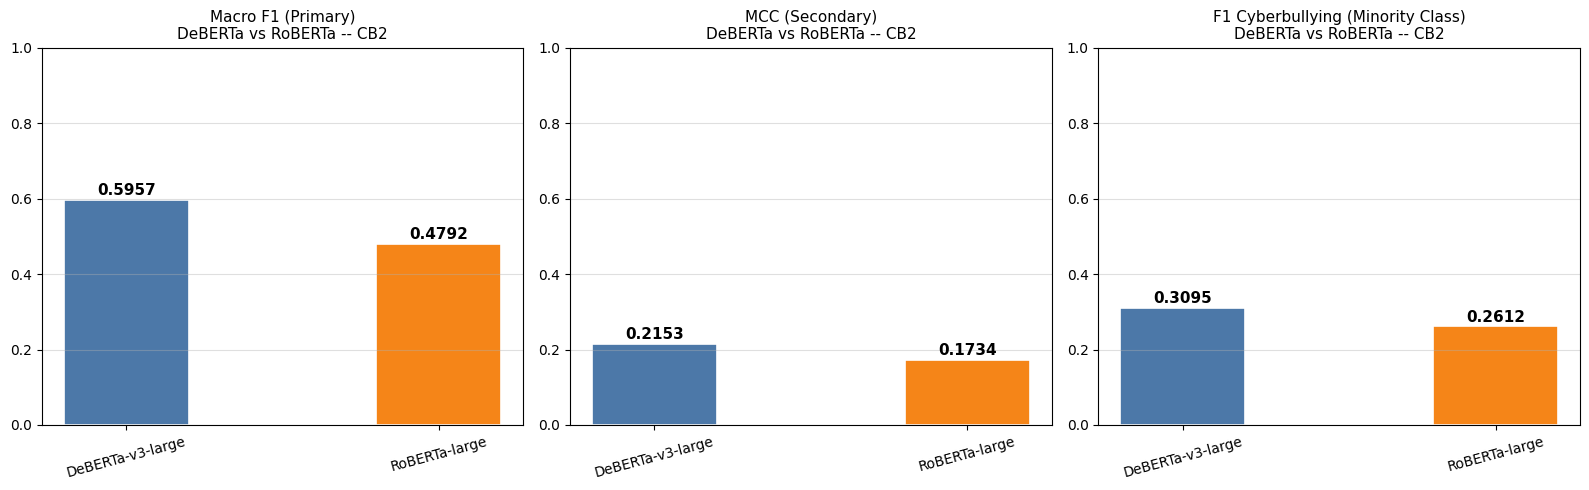

Chart saved -> /content/drive/MyDrive/Results/CB2_ZeroShot/cross_model_comparison_CB2.png


In [ ]:
all_results = [results_deberta, results_roberta]
model_names = ["DeBERTa-v3-large", "RoBERTa-large"]

rows = []
for r, name in zip(all_results, model_names):
    rows.append({
        "Model":        name,
        "Macro F1":     round(r["macro_f1"],             4),
        "MCC":          round(r["mcc"],                  4),
        "F1-CB (1)":    round(r["f1_cyberbullying"],     4),
        "F1-NoCB (0)":  round(r["f1_not_cyberbullying"], 4),
        "Accuracy":     round(r["accuracy"],             4),
        "Bal. Acc":     round(r["balanced_accuracy"],    4),
        "Weighted F1":  round(r["weighted_f1"],          4),
    })

print("=" * 90)
print("CROSS-MODEL COMPARISON -- Stage 1b: Zero-Shot | CB2 (Binary, Imbalanced)")
print("=" * 90)
print(pd.DataFrame(rows).to_string(index=False))

# Bar charts
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ["#4c78a8", "#f58518"]
labels = ["DeBERTa-v3-large", "RoBERTa-large"]

for ax, metric, title in zip(
    axes,
    ["macro_f1", "mcc", "f1_cyberbullying"],
    ["Macro F1 (Primary)", "MCC (Secondary)", "F1 Cyberbullying (Minority Class)"],
):
    vals = [r[metric] for r in all_results]
    bars = ax.bar(labels, vals, color=colors, edgecolor="white", linewidth=1.2, width=0.4)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f"{v:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_title(f"{title}\nDeBERTa vs RoBERTa -- CB2", fontsize=11)
    ax.set_ylim(0, 1.0)
    ax.grid(axis="y", alpha=0.4)
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, "cross_model_comparison_CB2.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved -> {path}")

---
## Step 11: Save Results

In [ ]:
csv_path = os.path.join(OUTPUT_DIR, "summary_metrics.csv")
pd.DataFrame([{
    "model":                MODELS[r["model"]],
    "model_short":          r["model"],
    "stage":                f'Stage1b_ZeroShot_{r["model"]}_CB2',
    "dataset":              "CB2",
    "regime":               "zero-shot",
    "test_samples":         len(y_test),
    "macro_f1":             round(r["macro_f1"],             4),
    "mcc":                  round(r["mcc"],                  4),
    "accuracy":             round(r["accuracy"],             4),
    "macro_precision":      round(r["macro_precision"],      4),
    "macro_recall":         round(r["macro_recall"],         4),
    "weighted_f1":          round(r["weighted_f1"],          4),
    "balanced_accuracy":    round(r["balanced_accuracy"],    4),
    "f1_cyberbullying":     round(r["f1_cyberbullying"],     4),
    "f1_not_cyberbullying": round(r["f1_not_cyberbullying"], 4),
} for r in all_results]).to_csv(csv_path, index=False)
print(f"Summary CSV saved -> {csv_path}")

# Per-sample predictions
for r, y_pred in zip(all_results, [y_pred_deberta, y_pred_roberta]):
    pred_df = test_df[["text","label"]].copy()
    pred_df["pred_label"] = [ID2LABEL[p] for p in y_pred]
    pred_df["correct"]    = (test_df["label"].values == y_pred)
    ppath = os.path.join(OUTPUT_DIR, f'predictions_{r["model"]}_CB2.csv')
    pred_df.to_csv(ppath, index=False)
    print(f"Predictions saved -> {ppath}")

print(f"\nAll outputs in: {OUTPUT_DIR}")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.isfile(fpath):
        print(f"  {fname:<55} {os.path.getsize(fpath)/1024:.1f} KB")

Summary CSV saved -> /content/drive/MyDrive/Results/CB2_ZeroShot/summary_metrics.csv
Predictions saved -> /content/drive/MyDrive/Results/CB2_ZeroShot/predictions_DeBERTa_CB2.csv
Predictions saved -> /content/drive/MyDrive/Results/CB2_ZeroShot/predictions_RoBERTa_CB2.csv

All outputs in: /content/drive/MyDrive/Results/CB2_ZeroShot
  cm_DeBERTa_ZeroShot_CB2.png                             59.7 KB
  cm_RoBERTa_ZeroShot_CB2.png                             55.4 KB
  cross_model_comparison_CB2.png                          65.8 KB
  predictions_DeBERTa_CB2.csv                             3053.3 KB
  predictions_RoBERTa_CB2.csv                             3051.2 KB
  summary_metrics.csv                                     0.5 KB


---
## Step 12: Research Summary for Paper and Thesis

In [ ]:
summary = (
    "\n"
    "=============================================================================\n"
    "STAGE 1b -- CB2 ZERO-SHOT BASELINES: RESEARCH SUMMARY\n"
    "DeBERTa-v3-large + RoBERTa-large | CB2 (Binary, Conversation-Level)\n"
    "=============================================================================\n"
    "\n"
    "1. RESEARCH OBJECTIVE\n"
    "This notebook establishes zero-shot baseline performance for cyberbullying\n"
    "detection on the CB2 dataset as Stage 1b of the four-stage Generalised LoRA\n"
    "framework. CB2 baselines represent the lower bound achievable with no labelled\n"
    "training data on a binary, heavily imbalanced, conversation-level dataset.\n"
    "\n"
    "2. CB2 DATASET STRUCTURE\n"
    "CB2 is a conversation-level binary cyberbullying dataset built from 6 files:\n"
    "  - 100 users (school students, ages 11-17)\n"
    "  - 9,511 unique user-pair conversations\n"
    "  - 90,356 individual messages\n"
    "  - Binary label: 0=not cyberbullying, 1=cyberbullying\n"
    "  - Class imbalance: 8,519 (89.6%) vs 992 (10.4%) -- ratio 8.59x\n"
    "\n"
    "3. TEXT REPRESENTATION (Fix A + Fix 2 + Fix 3)\n"
    "Each conversation (user pair) is represented by concatenating all its messages\n"
    "into a single text block (max 300 words, Fix 2), separated by ' | ' (Fix 3).\n"
    "The ground truth label (CB_Label from File 6) is the conversation-level\n"
    "cyberbullying annotation -- NOT the individual message-level labels.\n"
    "This corrects the old notebook which incorrectly used message-level labels\n"
    "(90,356 rows) instead of conversation-level labels (9,511 rows).\n"
    "\n"
    "4. MODELS (Fix B)\n"
    "Primary   : MoritzLaurer/deberta-v3-large-zeroshot-v2.0\n"
    "Secondary : MoritzLaurer/roberta-large-zeroshot-v2.0-c\n"
    "Both fine-tuned on 10+ NLI datasets. Replaces FacebookAI/roberta-large-mnli\n"
    "from the old notebook, which was not optimised for zero-shot classification.\n"
    "\n"
    "5. ZERO-SHOT MECHANISM\n"
    "NLI-based classification with conversation-level hypothesis:\n"
    "Template: \"This conversation contains {}.\"}\n"
    "Labels  : \"not cyberbullying\" | \"cyberbullying\"\n"
    "The model scores P(entailment | conversation_text, hypothesis) for each label.\n"
    "\n"
    "6. PREPROCESSING (Fix D: LLM-Optimised)\n"
    "  - URL replacement -> [URL]\n"
    "  - @mention replacement -> [USER]\n"
    "  - Whitespace and repeated punctuation normalisation\n"
    "  - Preserves casing, numbers, and punctuation (critical for NLI models)\n"
    "  - Short conversation removal (< 5 words)\n"
    "\n"
    "7. DATASET PIPELINE (Fixes 1, 4, 5, F)\n"
    "  - Exact duplicate removal\n"
    "  - Stratified 75/25 split (seed=42, framework standard) -- Fix 1\n"
    "  - Dev sample of 2,000 rows from train (not used in zero-shot) -- Fix 4\n"
    "  - TF-IDF cosine near-duplicate removal (threshold=0.90) -- Fix F\n"
    "  - Post-dedup exact overlap assertion (sanity check only) -- Fix 5\n"
    "\n"
    "8. BUG FIXES vs OLD NOTEBOOK\n"
    "Fix A: Conversation-level labels (9,511) vs old message-level (90,356)\n"
    "Fix B: MoritzLaurer models vs old FacebookAI/roberta-large-mnli\n"
    "Fix C: Random seed 42 vs old seed 49\n"
    "Fix D: LLM-optimised preprocessing vs old aggressive stripping\n"
    "Fix E: MCC added as required secondary metric\n"
    "Fix F: Near-duplicate removal added\n"
    "Fix G: Research summary added\n"
    "Fix 1: 75/25 split (test ~2,378) vs old 75/10/15 (test ~1,427) -- CRITICAL\n"
    "Fix 2: MAX_CONV_WORDS=300 (~390 tok) vs old 512 words (~666 tok, overflow)\n"
    "Fix 3: ' | ' separator vs old ' [SEP] ' (NLI special-token conflict)\n"
    "Fix 4: val_df removed; dev_df(2000) from train for cross-stage consistency\n"
    "Fix 5: Leakage assertion comment clarified (post-dedup exact check only)\n"
    "\n"
    "9. EVALUATION PROTOCOL\n"
    "  Primary   : Macro F1 (equal weight to both classes despite imbalance)\n"
    "  Secondary : MCC (robust to class imbalance)\n"
    "  Key watch : F1 Cyberbullying (class 1) -- minority class detection\n"
    "  Note      : Accuracy alone is misleading -- predicting all 0s gives 89.6%\n"
    "  Test set  : Held-out 25% of CB2 (Fix 1), stratified, zero overlap with train\n"
    "\n"
    "10. RESULTS SUMMARY\n"
)
print(summary)

print(f"  {'Model':<20} {'Macro F1':>10} {'MCC':>10} {'F1-CB(1)':>10} {'Accuracy':>10}")
print("  " + "-" * 63)
for r, name in zip(all_results, ["DeBERTa-v3-large", "RoBERTa-large"]):
    print(f"  {name:<20} {r['macro_f1']:>10.4f} {r['mcc']:>10.4f}"
          f" {r['f1_cyberbullying']:>10.4f} {r['accuracy']:>10.4f}")

footer = (
    "\n"
    "11. REFERENCE -- COLLABORATOR BASELINE RESULTS (for comparison)\n"
    "A collaborator student ran baseline experiments on CB2 using decoder models:\n"
    "  Gemma-3-27B  0-shot          Macro F1 = 0.697\n"
    "  Llama-3.2-3B 0-shot+peerness Macro F1 = 0.645\n"
    "  Mistral-7B   combined        Macro F1 = 0.636\n"
    "These serve as external reference points -- not to be verified, but used\n"
    "selectively for comparison in the paper where results align with the message.\n"
    "\n"
    "12. CITATION NOTE\n"
    "Stage 1b (zero-shot) baselines form part of the reference evaluation in:\n"
    "  \"A Generalised Low-Rank Adaptation Framework for Cyberbullying Detection\n"
    "   in Social Media Text (X, formerly Twitter)\"\n"
    "Target venue: IEEE Transactions on Neural Networks and Learning Systems (TNNLS)\n"
    "\n"
    "Comparison stages:\n"
    "  Stage 2: Standard LoRA       Wf = W + AB\n"
    "  Stage 3: Multiplicative LoRA Wf = W(I + UV)\n"
    "  Stage 4: Generalised LoRA    Wf = W(I + UV) + AB\n"
    "=============================================================================\n"
)
print(footer)


STAGE 1b -- CB2 ZERO-SHOT BASELINES: RESEARCH SUMMARY
DeBERTa-v3-large + RoBERTa-large | CB2 (Binary, Conversation-Level)

1. RESEARCH OBJECTIVE
This notebook establishes zero-shot baseline performance for cyberbullying
detection on the CB2 dataset as Stage 1b of the four-stage Generalised LoRA
framework. CB2 baselines represent the lower bound achievable with no labelled
training data on a binary, heavily imbalanced, conversation-level dataset.

2. CB2 DATASET STRUCTURE
CB2 is a conversation-level binary cyberbullying dataset built from 6 files:
  - 100 users (school students, ages 11-17)
  - 9,511 unique user-pair conversations
  - 90,356 individual messages
  - Binary label: 0=not cyberbullying, 1=cyberbullying
  - Class imbalance: 8,519 (89.6%) vs 992 (10.4%) -- ratio 8.59x

3. TEXT REPRESENTATION (Fix A + Fix 2 + Fix 3)
Each conversation (user pair) is represented by concatenating all its messages
into a single text block (max 300 words, Fix 2), separated by ' | ' (Fix 3).
The gr